# Import Libraries

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Load Dataset

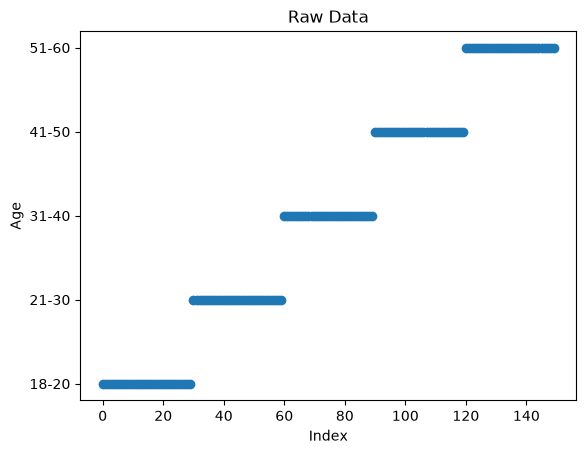

In [162]:
df = pd.read_csv('age_detection.csv')
df.head()

plt.scatter(df.index, df['age'])
plt.xlabel("Index")
plt.ylabel("Age")
plt.title("Raw Data")
plt.show()

# Data Preprocessing

In [163]:
def convert_age(x):
    a, b = x.split('-')
    return (int(a) + int(b)) / 2

df['age'] = df['age'].apply(convert_age)

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

df['feature'] = df.index

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

X_train = train_df[['feature']]
X_test = test_df[['feature']]
y_train = train_df['age']
y_test = test_df['age']

# LAB 1: Regression

## Simple Linear Regression

In [164]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

print("Simple MSE:", mean_squared_error(y_test, y_pred_simple))
print("Simple R2:", r2_score(y_test, y_pred_simple))

Simple MSE: 21.72325284905935
Simple R2: 0.8751250123645703


## Multiple Linear Regression

In [165]:
train_df['feature2'] = train_df['feature']**2
test_df['feature2'] = test_df['feature']**2

X_train_multi = train_df[['feature','feature2']]
X_test_multi = test_df[['feature','feature2']]

model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train)

y_pred_multi = model_multi.predict(X_test_multi)

print("Multiple MSE:", mean_squared_error(y_test, y_pred_multi))
print("Multiple R2:", r2_score(y_test, y_pred_multi))

Multiple MSE: 21.738817869602677
Multiple R2: 0.8750355376546178


## Age Prediction

Actual: [19. 19. 19. 19. 19.]
Predicted: [22.2091859  22.46617185 22.7241107  22.98300245 23.2428471 ]
MSE: 21.72325284905935
R2: 0.8751250123645703


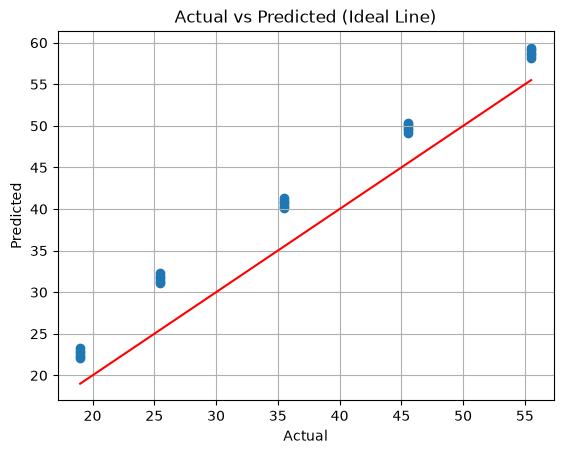

In [166]:
print("Actual:", y_test.head().values)
print("Predicted:", y_pred_multi[:5])


mse = mean_squared_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("MSE:", mse)
print("R2:", r2)

plt.scatter(y_test, y_pred_simple)


plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Ideal Line)")
plt.grid()
plt.show()


# LAB 2: Classification

## Preparing Classification Data

In [167]:
def age_group(x):
    return 0 if x < 30 else 1

train_df['age_group'] = train_df['age'].apply(age_group)
test_df['age_group'] = test_df['age'].apply(age_group)

y_train_cls = train_df['age_group']
y_test_cls = test_df['age_group']

## Logistic Regression

In [168]:
model_clf = LogisticRegression()
model_clf.fit(X_train_multi, y_train_cls)

y_pred_cls = model_clf.predict(X_test_multi)

## Gender Prediction

In [169]:
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))

Accuracy: 0.92


## Confusion Matrix

In [170]:

print(confusion_matrix(y_test_cls, y_pred_cls))
print(classification_report(y_test_cls, y_pred_cls))

[[ 8  2]
 [ 0 15]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.88      1.00      0.94        15

    accuracy                           0.92        25
   macro avg       0.94      0.90      0.91        25
weighted avg       0.93      0.92      0.92        25



# LAB 3: Model Comparison

## Simple vs Multiple Linear Regression

In [171]:
print("Simple R2:", r2_score(y_test, y_pred_simple))
print("Multiple R2:", r2_score(y_test, y_pred_multi))

Simple R2: 0.8751250123645703
Multiple R2: 0.8750355376546178


## Training vs Testing Performance

In [172]:
train_pred = model_multi.predict(X_train_multi)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred_multi))

Train R2: 0.9698978989080056
Test R2: 0.8750355376546178


## Regression vs Classification

In [173]:
print("Regression → Predict age (continuous)")
print("Classification → Predict group (0/1)")

Regression → Predict age (continuous)
Classification → Predict group (0/1)


## Model Performance Metrics

In [174]:
print("Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("R2:", r2_score(y_test, y_pred_multi))

print("\nClassification:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))

Regression:
MSE: 21.738817869602677
R2: 0.8750355376546178

Classification:
Accuracy: 0.92
